# CNN (8-Conv) + mRMR + SVM Hybrid
**Pipeline:** Custom 8-layer CNN → 512-d FC embeddings → mRMR feature selection → SVM classifier  
**Improvements:** Batch Normalisation · Data Augmentation · OneCycleLR · AMP (FP16)  
All outputs saved to `8conResults/`

In [1]:
# ================================================
# Cell 1 — Imports & Config
# ================================================
# ── Standard library and scientific computing ─────────────────
# os/numpy/pandas/matplotlib/tqdm: I/O, arrays, results, charts
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ── PyTorch and sklearn pipeline ───────────────────────────────
# torch/nn/optim/F: model, layers, optimiser, activations
# sklearn: SVM, StandardScaler, mRMR, joblib
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import transforms, datasets


# Evaluation, StandardScaler, SVC, mutual_info_classif, dump
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.feature_selection import mutual_info_classif
from joblib import dump


# ── Paths ──────────────────────────────────────────────────────
# Same pre-split dataset as all other CNN experiments.
# ── Paths ──────────────────────────────────────
BASE_DATASET = "/home/jenarththan/Desktop/FYP/May11/Dataset"
TRAIN_PATH   = os.path.join(BASE_DATASET, "Training")
VAL_PATH     = os.path.join(BASE_DATASET, "Validation")
TEST_PATH    = os.path.join(BASE_DATASET, "Testing")

NOTEBOOK_DIR = "/home/jenarththan/Desktop/FYP/May11/Notebooks/Custom"
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, "CNN8_May11_Results")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


# ── Hyperparameters ────────────────────────────────────────────
# LR=1e-4    : trained from scratch
# K_MRMR=96  : 96 features from the 512-d embedding (same as CNN6/CNN7)
# No ImageNet normalisation — Resize + ToTensor only.
# ── Hyperparameters ─────────────────────────────
CLASS_NAMES     = ['0', '100', '500', '1000', '1500', '2000']
NUM_CLASSES     = len(CLASS_NAMES)
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 50
PATIENCE        = 5
MIN_EPOCHS_BEFORE_STOP = 20
LR              = 1e-4
SEED            = 42
TRAIN_PER_CLASS = 1750
VAL_PER_CLASS   = 250
K_MRMR          = 96
NUM_WORKERS     = 0


# CUDA required; cudnn.benchmark=True for fixed input size
# ── CUDA setup ──────────────────────────────────
if not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Check nvidia-smi, then re-run.")

DEVICE = torch.device('cuda')
torch.backends.cudnn.benchmark = True

print(f"GPU : {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


# Fix all random seeds for full reproducibility
rng = np.random.RandomState(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)


Output directory: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN8_May11_Results
GPU : NVIDIA GeForce RTX 3050 Ti Laptop GPU
VRAM: 4.0 GB


In [2]:
# ================================================
# Cell 2 — Dataset Loading
# ================================================
# Enforces numeric class order: 0, 100, 500, 1000, 1500, 2000
class OrderedImageFolder(datasets.ImageFolder):
    """ImageFolder with a fixed class order instead of alphabetical."""
    def find_classes(self, directory):
        classes = CLASS_NAMES
        class_to_idx = {c: i for i, c in enumerate(classes)}
        missing = [c for c in classes if c not in os.listdir(directory)]
        if missing:
            raise FileNotFoundError(f"Missing class folders in {directory}: {missing}")
        return classes, class_to_idx


# Resize + ToTensor only — no ImageNet normalisation or augmentation
transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
])


# Load all three pre-split dataset folders
# Load directly from pre-split folders (no Subset needed)
train_ds = OrderedImageFolder(root=TRAIN_PATH, transform=transform)
val_ds   = OrderedImageFolder(root=VAL_PATH,   transform=transform)
test_ds  = OrderedImageFolder(root=TEST_PATH,  transform=transform)

assert train_ds.classes == CLASS_NAMES, "Train class order mismatch!"
assert val_ds.classes   == CLASS_NAMES, "Val class order mismatch!"
assert test_ds.classes  == CLASS_NAMES, "Test class order mismatch!"

print(f"Classes    : {CLASS_NAMES}")
print(f"Train      : {len(train_ds):,} images  ({len(train_ds)//NUM_CLASSES} per class)")
print(f"Validation : {len(val_ds):,} images  ({len(val_ds)//NUM_CLASSES} per class)")
print(f"Test       : {len(test_ds):,} images  ({len(test_ds)//NUM_CLASSES} per class)")


# train_loader: shuffled | val/test loaders: unshuffled
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

print("Data loaders ready.")


Classes    : ['0', '100', '500', '1000', '1500', '2000']
Train      : 10,500 images  (1750 per class)
Validation : 1,500 images  (250 per class)
Test       : 3,000 images  (500 per class)
Data loaders ready.


In [3]:
# ================================================
# Cell 3 — Model: Custom 8-Conv CNN + Batch Normalisation
# ================================================
# Every conv block: Conv(bias=False) -> BN -> ReLU
# bias=False because BN has its own learnable bias (gamma/beta).
#
# Spatial flow (224x224 input):
#   conv1+pool->112 | conv2+pool->56 | conv3+pool->28
#   conv4+pool->14  | conv5+pool->7  | conv6+pool->3
#   conv7 (no pool) | conv8 (no pool) -> AdaptiveAvgPool(1,1)
# Channel flow: 3->32->64->128->256->512->1024->2048->2048
# FC: 2048->512 (embedding for SVM) -> num_classes
# ================================================
# ── Model architecture — Custom8CNN ────────────────────────────
# Most sophisticated custom architecture, introducing Batch Normalisation
# after every convolutional layer (Conv -> BN -> ReLU pattern).
#
# Key differences from CNN7:
#   1. Batch Normalisation (BN): normalises layer activations to zero
#      mean and unit variance per mini-batch. Stabilises training,
#      reduces internal covariate shift, and acts as a regulariser.
#   2. bias=False on all conv layers: BN has its own learnable offset
#      parameter (beta) that makes the conv bias redundant — omitting
#      it reduces parameter count without losing representational power.
#   3. AdamW optimiser: decouples L2 weight decay from the gradient
#      update (unlike Adam which conflates the two), providing better
#      regularisation for larger models.
#   4. conv7 AND conv8 both have no MaxPool — two consecutive layers
#      operate at the 3x3 spatial scale before AdaptiveAvgPool.
#
# Despite these improvements, CNN8 achieves only 67.07% CNN accuracy
# (worst among CNN5-CNN8). However, mRMR+SVM recovers performance
# to 73.63% — the largest improvement (+6.56%) of any custom model.
# This suggests CNN8's BN-normalised features are well-suited for
# the SVM kernel despite the CNN head underperforming.
#
# Spatial flow: 224->112->56->28->14->7->3 (conv6+pool)
#               -> 3 (conv7, no pool) -> 3 (conv8, no pool) -> 1x1
# Channel flow: 3->32->64->128->256->512->1024->2048->2048
class Custom8CNN(nn.Module):
    def __init__(self, num_classes=6, p_drop=0.5):
        super().__init__()
        self.conv1 = nn.Conv2d(3,    32,   3, padding=1, bias=False); self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(32,   64,   3, padding=1, bias=False); self.bn2 = nn.BatchNorm2d(64)
        self.conv3 = nn.Conv2d(64,   128,  3, padding=1, bias=False); self.bn3 = nn.BatchNorm2d(128)
        self.conv4 = nn.Conv2d(128,  256,  3, padding=1, bias=False); self.bn4 = nn.BatchNorm2d(256)
        self.conv5 = nn.Conv2d(256,  512,  3, padding=1, bias=False); self.bn5 = nn.BatchNorm2d(512)
        self.conv6 = nn.Conv2d(512,  1024, 3, padding=1, bias=False); self.bn6 = nn.BatchNorm2d(1024)
        self.conv7 = nn.Conv2d(1024, 2048, 3, padding=1, bias=False); self.bn7 = nn.BatchNorm2d(2048)
        self.conv8 = nn.Conv2d(2048, 2048, 3, padding=1, bias=False); self.bn8 = nn.BatchNorm2d(2048)

        self.pool          = nn.MaxPool2d(2, 2)
        self.adaptive_pool = nn.AdaptiveAvgPool2d((1, 1))
        self.dropout       = nn.Dropout(p_drop)
        self.fc1           = nn.Linear(2048, 512)
        self.fc2           = nn.Linear(512, num_classes)
        self.feature_maps  = None

    def _cbr(self, x, conv, bn):
        """Conv -> BN -> ReLU block."""
        return F.relu(bn(conv(x)))

    def forward(self, x, return_embedding=False):
        x = self.pool(self._cbr(x, self.conv1, self.bn1))  # 224->112
        x = self.pool(self._cbr(x, self.conv2, self.bn2))  # 112-> 56
        x = self.pool(self._cbr(x, self.conv3, self.bn3))  #  56-> 28
        x = self.pool(self._cbr(x, self.conv4, self.bn4))  #  28-> 14
        x = self.pool(self._cbr(x, self.conv5, self.bn5))  #  14->  7
        x = self.pool(self._cbr(x, self.conv6, self.bn6))  #   7->  3
        x = self._cbr(x, self.conv7, self.bn7)             # keeps 3x3
        x = self._cbr(x, self.conv8, self.bn8)             # keeps 3x3 -> GAP
        self.feature_maps = x
        x   = self.adaptive_pool(x).view(x.size(0), -1)    # (B, 2048)
        emb = F.relu(self.fc1(x))                          # (B, 512) embedding
        logits = self.fc2(self.dropout(emb))
        if return_embedding:
            return logits, emb
        return logits

model     = Custom8CNN(num_classes=NUM_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss()
# AdamW: decoupled weight decay (1e-4) for better regularisation
# than standard Adam on larger models with BN
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Custom8CNN (BN) — trainable parameters: {total_params:,}")

Custom8CNN (BN) — trainable parameters: 63,973,670


/tmp/ipykernel_33083/390610889.py:10: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler()


Epoch 1/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_33083/390610889.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():       # FP16 forward


Epoch 1/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

/tmp/ipykernel_33083/390610889.py:65: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


...

Epoch 19/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 19]  Train Acc: 0.9461  Val Acc: 0.5840  Train Loss: 0.1508  Val Loss: 1.6642  LR: 9.68e-05
  -> No improvement for 17/5, but continuing until at least epoch 20.


Epoch 20/50 [Train]:   0%|          | 0/329 [00:00<?, ?it/s]

Epoch 20/50 [Val]:   0%|          | 0/47 [00:00<?, ?it/s]

[Epoch 20]  Train Acc: 0.9510  Val Acc: 0.7120  Train Loss: 0.1376  Val Loss: 1.2559  LR: 9.50e-05
Early stopping at epoch 20 after 18 epochs without improvement.

Training complete. Best model -> /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN8_May11_Results/best_custom_8cnn_model.pth


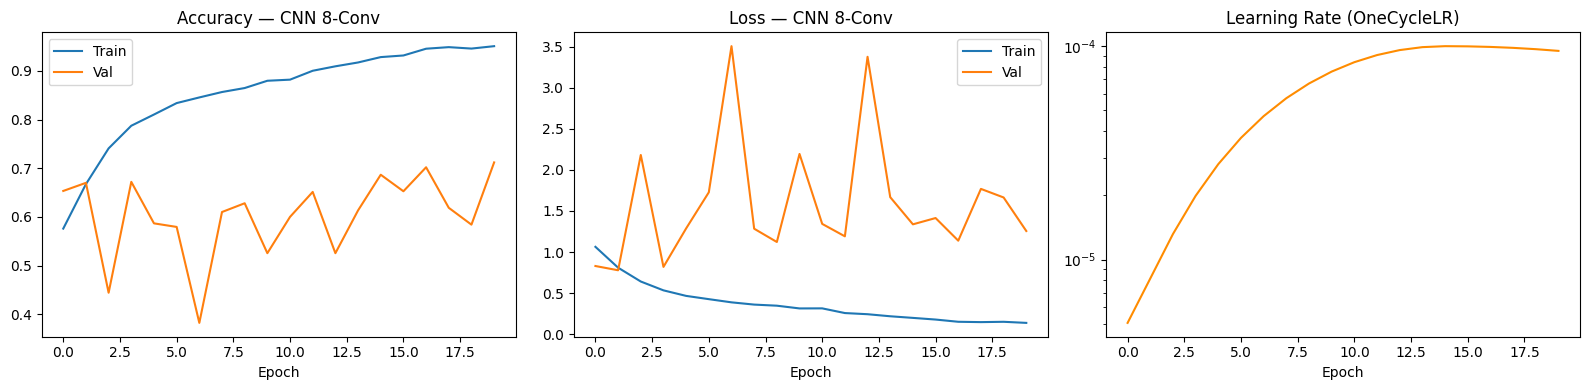

Training curves saved.


In [4]:
# ================================================
# Cell 4 — Training: AMP + OneCycleLR + Early Stopping
# ================================================
# OneCycleLR  : warms up LR for 30% of training then cosine-anneals to near 0.
#               Steps every BATCH (not epoch) — must call scheduler.step() inside loop.
# GradScaler  : prevents FP16 underflow during AMP backward pass.
# ================================================
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_custom_8cnn_model.pth")

scaler_amp = torch.cuda.amp.GradScaler()

scheduler = optim.lr_scheduler.OneCycleLR(
    optimizer,
    max_lr          = LR,
    steps_per_epoch = len(train_loader),
    epochs          = EPOCHS,
    pct_start       = 0.3,
    anneal_strategy = "cos",
)


# Track best val_loss; save model whenever it improves
best_val_loss     = float('inf')
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []
lr_hist = []


# ── Training loop: train -> validate -> early stop -> save best ──
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)

        with torch.cuda.amp.autocast():       # FP16 forward
            outputs = model(inputs)
            loss    = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()     # scaled backward
        scaler_amp.step(optimizer)
        scaler_amp.update()
        scheduler.step()                      # step per BATCH

        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)
    lr_hist.append(scheduler.get_last_lr()[0])

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs, labels = inputs.to(DEVICE, non_blocking=True), labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast():
                outputs = model(inputs)
                loss    = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc   = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}  "
          f"LR: {lr_hist[-1]:.2e}")

    # ── Early stopping ──
    if val_loss < best_val_loss:
        best_val_loss     = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")

# ── Learning curves: Accuracy | Loss | LR schedule ──
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(train_acc_hist, label='Train'); axes[0].plot(val_acc_hist, label='Val')
axes[0].set_title("Accuracy — CNN 8-Conv"); axes[0].set_xlabel("Epoch"); axes[0].legend()

axes[1].plot(train_loss_hist, label='Train'); axes[1].plot(val_loss_hist, label='Val')
axes[1].set_title("Loss — CNN 8-Conv"); axes[1].set_xlabel("Epoch"); axes[1].legend()

axes[2].plot(lr_hist, color='darkorange')
axes[2].set_title("Learning Rate (OneCycleLR)"); axes[2].set_xlabel("Epoch")
axes[2].set_yscale("log")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Training curves saved.")


     #    True Label    Pred Label   Correct


Inference:   0%|          | 0/94 [00:00<?, ?it/s]

     0             0           500       NO 
     1             0             0       YES
     2             0             0       YES
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0             0       YES
     7             0           500       NO 
     8             0           500       NO 
     9             0             0       YES
    10             0             0       YES
    11             0          1500       NO 
    12             0             0       YES
    13             0             0       YES
    14             0          2000       NO 
    15             0             0       YES
    16             0             0       YES
    17             0             0       YES
    18             0             0       YES
    19             0             0       YES
    20             0             0       YES
    21             0             0       YES
    22    

/tmp/ipykernel_33083/2501207790.py:19: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


    64             0             0       YES
    65             0             0       YES
    66             0             0       YES
    67             0             0       YES
    68             0             0       YES
    69             0             0       YES
    70             0             0       YES
    71             0             0       YES
    72             0             0       YES
    73             0             0       YES
    74             0             0       YES
    75             0             0       YES
    76             0             0       YES
    77             0             0       YES
    78             0             0       YES
    79             0             0       YES
    80             0             0       YES
    81             0             0       YES
    82             0             0       YES
    83             0             0       YES
    84             0             0       YES
    85             0             0       YES
    86    

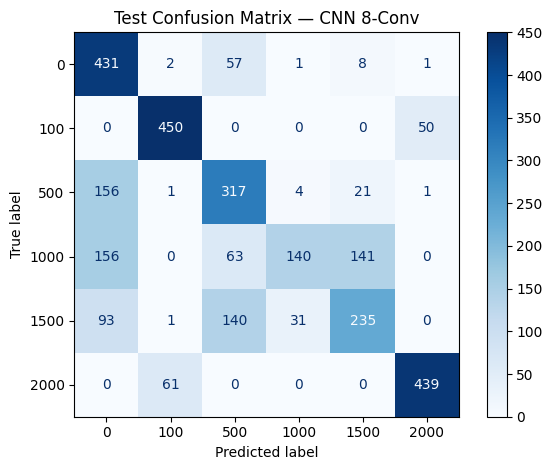


Classification Report — CNN 8-Conv:
              precision    recall  f1-score   support

           0     0.5156    0.8620    0.6452       500
         100     0.8738    0.9000    0.8867       500
         500     0.5494    0.6340    0.5887       500
        1000     0.7955    0.2800    0.4142       500
        1500     0.5802    0.4700    0.5193       500
        2000     0.8941    0.8780    0.8860       500

    accuracy                         0.6707      3000
   macro avg     0.7014    0.6707    0.6567      3000
weighted avg     0.7014    0.6707    0.6567      3000



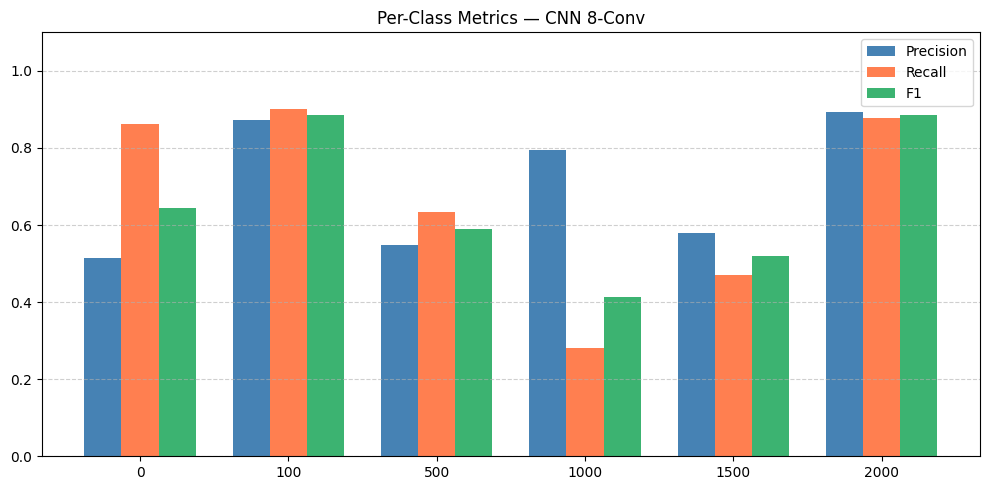

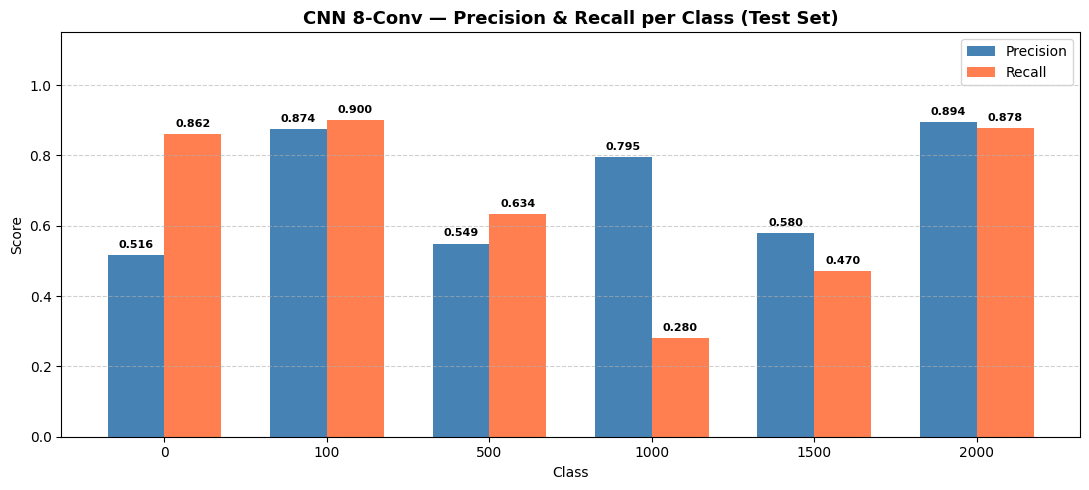

CNN Precision & Recall chart saved.


/tmp/ipykernel_33083/2501207790.py:116: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():
/tmp/ipykernel_33083/2501207790.py:127: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():



CNN 8-Conv — Inference Time (100 random samples)
  Average : 5.915 ms / sample
  Std Dev : 0.132 ms
  Min     : 5.812 ms
  Max     : 6.447 ms
CNN inference times saved.


In [5]:
# ================================================
# Cell 5 — CNN Test Evaluation + Inference Print
# ================================================
import time

# Load best checkpoint (lowest val_loss) for evaluation
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
sample_idx = 0

print("\n" + "="*65)
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)

with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE)
        with torch.cuda.amp.autocast():
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        for i in range(len(preds)):
            true_name = CLASS_NAMES[labels[i]]
            pred_name = CLASS_NAMES[preds[i]]
            correct   = "YES" if preds[i] == labels[i].item() else "NO "
            print(f"{sample_idx:>6}  {true_name:>12}  {pred_name:>12}  {correct:>8}")
            sample_idx += 1

print("="*65)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
test_acc   = (all_preds == all_labels).mean()
print(f"\nTest Accuracy (CNN 8-Conv): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


# Confusion matrix across all 6 milling classes
# ── Confusion Matrix ──
cm   = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title("Test Confusion Matrix — CNN 8-Conv")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_cnn.png"), dpi=150)
plt.show()


# Per-class precision, recall, F1 — saved as .txt and .csv
# ── Classification Report ──
report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report — CNN 8-Conv:")
print(report_txt)
with open(os.path.join(OUTPUT_DIR, "classification_report_cnn.txt"), "w") as f:
    f.write(report_txt)
pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, "classification_report_cnn.csv"))


# Grouped bar charts: Precision / Recall / F1 per class
# ── Per-class metrics ──
cnn_precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
cnn_recall    = recall_score(all_labels,    all_preds, average=None, labels=range(NUM_CLASSES))
cnn_f1        = f1_score(all_labels,        all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, cnn_precision, w, label='Precision', color='steelblue')
plt.bar(x,     cnn_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, cnn_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title("Per-Class Metrics — CNN 8-Conv")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_cnn.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, cnn_precision, w2, label='Precision', color='steelblue')
plt.bar(x + w2/2, cnn_recall,    w2, label='Recall',    color='coral')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, cnn_precision[i] + 0.02, f'{cnn_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, cnn_recall[i]    + 0.02, f'{cnn_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 8-Conv — Precision & Recall per Class (Test Set)", fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_cnn.png"), dpi=150)
plt.show()
print("CNN Precision & Recall chart saved.")


# Per-sample true label, predicted label, correct flag
# ── Raw predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(all_labels)),
    "True Label": [CLASS_NAMES[i] for i in all_labels],
    "Pred Label": [CLASS_NAMES[i] for i in all_preds],
    "Correct":    (all_preds == all_labels).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, "predictions_cnn.csv"), index=False)

# ================================================
# CNN Inference Time — 100 random test samples
# ================================================
_rng100        = np.random.RandomState(SEED)
_sample_idx    = _rng100.choice(len(test_ds), 100, replace=False)
_timing_loader = DataLoader(Subset(test_ds, _sample_idx), batch_size=1,
                            shuffle=False, num_workers=0)

with torch.no_grad():
    _warm, _ = next(iter(_timing_loader))
    with torch.cuda.amp.autocast():
        _ = model(_warm.to(DEVICE))
torch.cuda.synchronize()

cnn_times_ms = []
model.eval()
with torch.no_grad():
    for _inp, _ in _timing_loader:
        _inp = _inp.to(DEVICE)
        torch.cuda.synchronize()
        _t0 = time.perf_counter()
        with torch.cuda.amp.autocast():
            _ = model(_inp)
        torch.cuda.synchronize()
        cnn_times_ms.append((time.perf_counter() - _t0) * 1000)

cnn_avg_time_ms = float(np.mean(cnn_times_ms))
cnn_std_time_ms = float(np.std(cnn_times_ms))

print("\n" + "="*52)
print("CNN 8-Conv — Inference Time (100 random samples)")
print("="*52)
print(f"  Average : {cnn_avg_time_ms:.3f} ms / sample")
print(f"  Std Dev : {cnn_std_time_ms:.3f} ms")
print(f"  Min     : {np.min(cnn_times_ms):.3f} ms")
print(f"  Max     : {np.max(cnn_times_ms):.3f} ms")
print("="*52)

pd.DataFrame({"sample": range(100), "cnn_time_ms": cnn_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, "cnn_inference_times.csv"), index=False)
print("CNN inference times saved.")

In [6]:
# ================================================
# Cell 6 — Feature Extraction  (save embeddings)
# ================================================
# ── Feature extraction ─────────────────────────────────────────
# Extracts 512-d embeddings (fc1 output).
# BN-normalised features are well-conditioned for the SVM kernel,
# explaining the large +6.56% SVM improvement over CNN-alone.
def extract_embeddings(loader, model, split_name):
    model.eval()
    embs, ys = [], []
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Extracting [{split_name}]", leave=False):
            inputs = inputs.to(DEVICE)
            with torch.cuda.amp.autocast():
                _, emb = model(inputs, return_embedding=True)  # (B, 512)
            embs.append(emb.cpu().float().numpy())
            ys.append(labels.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(ys, axis=0)

train_embs, train_y = extract_embeddings(train_loader, model, "train")
val_embs,   val_y   = extract_embeddings(val_loader,   model, "val")
test_embs,  test_y  = extract_embeddings(test_loader,  model, "test")

print(f"Embedding shapes -> train: {train_embs.shape}  val: {val_embs.shape}  test: {test_embs.shape}")

for name, arr in [("train_embs", train_embs), ("val_embs",  val_embs),
                  ("test_embs",  test_embs),  ("train_y",   train_y),
                  ("val_y",      val_y),       ("test_y",    test_y)]:
    np.save(os.path.join(OUTPUT_DIR, f"{name}.npy"), arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

print("\nAll embeddings saved.")

Extracting [train]:   0%|          | 0/329 [00:00<?, ?it/s]

/tmp/ipykernel_33083/3980911065.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast():


Extracting [val]:   0%|          | 0/47 [00:00<?, ?it/s]

Extracting [test]:   0%|          | 0/94 [00:00<?, ?it/s]

Embedding shapes -> train: (10500, 512)  val: (1500, 512)  test: (3000, 512)
  Saved train_embs.npy  shape=(10500, 512)
  Saved val_embs.npy  shape=(1500, 512)
  Saved test_embs.npy  shape=(3000, 512)
  Saved train_y.npy  shape=(10500,)
  Saved val_y.npy  shape=(1500,)
  Saved test_y.npy  shape=(3000,)

All embeddings saved.


Running mRMR: 12000 samples, 512 features -> selecting K=96 ...


/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/jenarththan/Desktop/FYP/venv/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]



Top 10 selected features (by MI):
 feature_index       mi
           200 0.924639
           118 0.907731
           204 0.904957
           341 0.903774
           333 0.899356
            63 0.894619
           418 0.868699
           322 0.864006
           327 0.862473
           324 0.857562


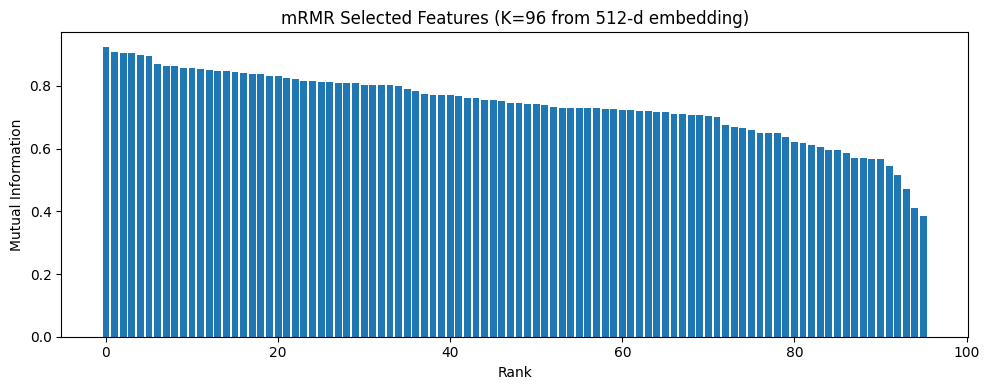

Reduced embedding: 96-d


In [7]:
# ================================================
# Cell 7 — mRMR Feature Selection
# ================================================
# ── mRMR greedy feature selection ──────────────────────────────
# Selects K=96 from 512-d BN-normalised embeddings.
# This step provides the biggest accuracy boost of all custom models
# (+6.56%), suggesting CNN8's BN features benefit greatly from
# dimensionality reduction and the SVM non-linear kernel.
def mrmr_select(X, y, k, seed=SEED):
    """
    Greedy mRMR:
      relevance  = MI(feature, label)
      redundancy = mean |corr| to already-selected features
      score      = relevance - redundancy
    """
    X, y = np.asarray(X), np.asarray(y)
    k    = min(k, X.shape[1])
    mi   = mutual_info_classif(X, y, random_state=seed, discrete_features=False)
    corr = np.nan_to_num(np.abs(np.corrcoef(X, rowvar=False)), nan=0.0)

    selected  = [int(np.argmax(mi))]
    candidate = set(range(X.shape[1])) - set(selected)

    while len(selected) < k and candidate:
        scores    = {f: mi[f] - np.mean(corr[f, selected]) for f in candidate}
        best_feat = max(scores, key=scores.get)
        selected.append(best_feat)
        candidate.remove(best_feat)

    return selected, mi


# Combine train+val for more reliable MI estimation
X_tv = np.vstack([train_embs, val_embs])
y_tv = np.hstack([train_y,   val_y])

print(f"Running mRMR: {X_tv.shape[0]} samples, {X_tv.shape[1]} features -> selecting K={K_MRMR} ...")
selected_idx, mi = mrmr_select(X_tv, y_tv, k=K_MRMR)

sel_df = (pd.DataFrame({"feature_index": selected_idx, "mi": mi[selected_idx]})
            .sort_values("mi", ascending=False).reset_index(drop=True))
sel_df.to_csv(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}.csv"), index=False)

print(f"\nTop 10 selected features (by MI):")
print(sel_df.head(10).to_string(index=False))

plt.figure(figsize=(10, 4))
plt.bar(range(K_MRMR), sel_df["mi"].values)
plt.xlabel("Rank"); plt.ylabel("Mutual Information")
plt.title(f"mRMR Selected Features (K={K_MRMR} from 512-d embedding)")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"mrmr_selected_{K_MRMR}_plot.png"), dpi=150)
plt.show()


# Reduce 512-d to 96-d using mRMR-selected indices
train_sel = train_embs[:, selected_idx]
val_sel   = val_embs[:,   selected_idx]
test_sel  = test_embs[:,  selected_idx]
print(f"Reduced embedding: {train_sel.shape[1]}-d")

Training SVM (RBF, C=10) ...
SVM training done.

SVM INFERENCE — per sample
     #    True Label    Pred Label   Correct
     0             0           500       NO 
     1             0           500       NO 
     2             0             0       YES
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0           500       NO 
     7             0           500       NO 
     8             0           500       NO 
     9             0             0       YES
    10             0           500       NO 
    11             0          1000       NO 
    12             0             0       YES
    13             0             0       YES
    14             0           500       NO 
    15             0             0       YES
    16             0             0       YES
    17             0             0       YES
    18             0           500       NO 
    19             0    

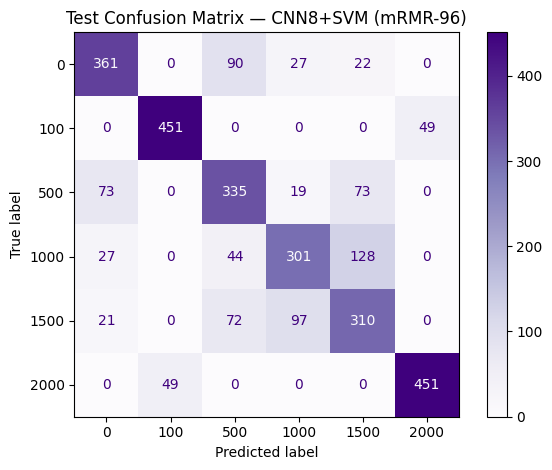


Classification Report — CNN8+SVM (mRMR-96):
              precision    recall  f1-score   support

           0     0.7490    0.7220    0.7352       500
         100     0.9020    0.9020    0.9020       500
         500     0.6192    0.6700    0.6436       500
        1000     0.6779    0.6020    0.6377       500
        1500     0.5816    0.6200    0.6002       500
        2000     0.9020    0.9020    0.9020       500

    accuracy                         0.7363      3000
   macro avg     0.7386    0.7363    0.7368      3000
weighted avg     0.7386    0.7363    0.7368      3000



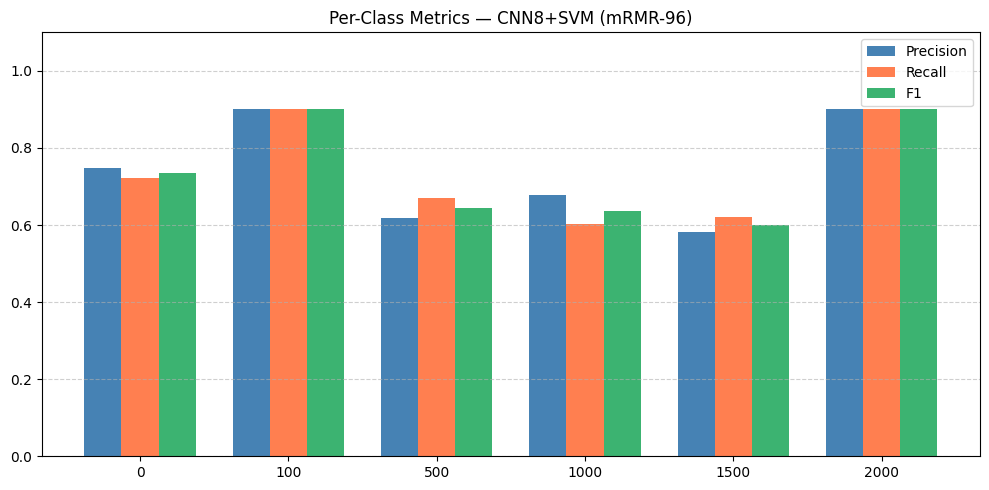

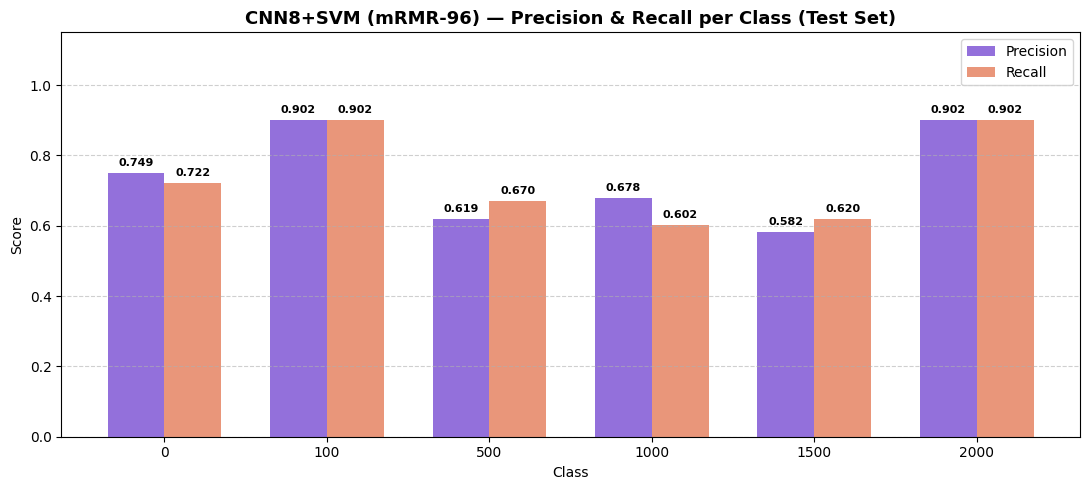

SVM Precision & Recall chart saved.


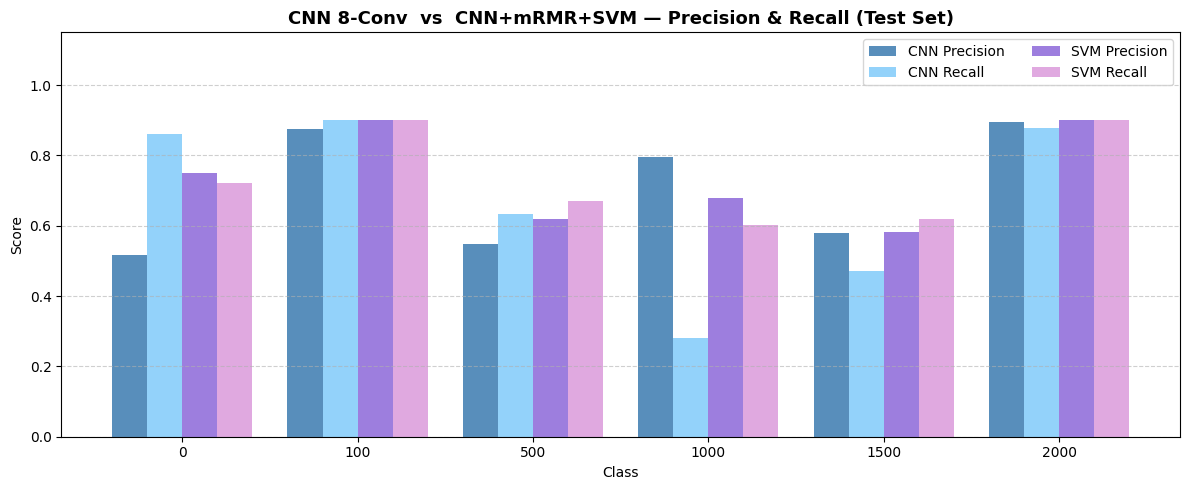

CNN vs SVM comparison chart saved.

SVM (mRMR-96) — Inference Time (100 random samples)
  Average : 0.5696 ms / sample
  Std Dev : 0.0643 ms
  Min     : 0.4762 ms
  Max     : 0.7849 ms

INFERENCE TIME SUMMARY (avg over 100 samples)
  CNN alone        : 5.915 ± 0.132 ms
  SVM alone (mRMR) : 0.5696 ± 0.0643 ms
  Full pipeline    : 6.485 ms  (CNN + SVM)

All artifacts saved in: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN8_May11_Results
best_custom_8cnn_model.pth
classification_report_cnn.csv
classification_report_cnn.txt
classification_report_svm_mrmr_96.csv
classification_report_svm_mrmr_96.txt
cnn_inference_times.csv
comparison_cnn_vs_svm_precision_recall.png
confusion_matrix_cnn.png
confusion_matrix_svm_mrmr_96.png
inference_time_summary.csv
mrmr_selected_96.csv
mrmr_selected_96_plot.png
per_class_metrics_cnn.png
per_class_metrics_svm_mrmr_96.png
precision_recall_cnn.png
precision_recall_svm_mrmr_96.png
predictions_cnn.csv
predictions_svm_mrmr_96.csv
scaler_mrmr_svm.joblib

In [8]:
# ================================================
# Cell 8 — SVM Training + Evaluation + Inference
# ================================================
# ── SVM pipeline ───────────────────────────────────────────────
# StandardScaler normalises 96-d features; fitted on train+val only.
# BN outputs are already normalised per-channel, but StandardScaler
# applies global normalisation across the mRMR-selected feature set.
scaler       = StandardScaler()
train_std    = scaler.fit_transform(np.vstack([train_sel, val_sel]))
test_std     = scaler.transform(test_sel)
y_train_full = np.hstack([train_y, val_y])

print("Training SVM (RBF, C=10) ...")
svm = SVC(kernel="rbf", C=10.0, gamma="scale", probability=False, random_state=SEED)
svm.fit(train_std, y_train_full)
print("SVM training done.")


# Save scaler and SVM for future inference
dump(scaler, os.path.join(OUTPUT_DIR, "scaler_mrmr_svm.joblib"))
dump(svm,    os.path.join(OUTPUT_DIR, "svm_mrmr_rbf.joblib"))


# Run SVM predictions on the full test set
# ── SVM Inference per sample ──
svm_preds = svm.predict(test_std)

print("\n" + "="*65)
print("SVM INFERENCE — per sample")
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)
for i, (true, pred) in enumerate(zip(test_y, svm_preds)):
    correct = "YES" if true == pred else "NO "
    print(f"{i:>6}  {CLASS_NAMES[true]:>12}  {CLASS_NAMES[pred]:>12}  {correct:>8}")
print("="*65)

svm_acc = (svm_preds == test_y).mean()
print(f"\nTest Accuracy (CNN8 + mRMR-{K_MRMR} + SVM): {svm_acc * 100:.2f}%")
print(f"Correct: {(svm_preds == test_y).sum()} / {len(test_y)}")


# Confusion matrix across all 6 milling classes
# ── Confusion Matrix ──
cm_svm = confusion_matrix(test_y, svm_preds, labels=list(range(NUM_CLASSES)))
disp   = ConfusionMatrixDisplay(confusion_matrix=cm_svm, display_labels=CLASS_NAMES)
disp.plot(cmap='Purples', values_format='d')
plt.title(f"Test Confusion Matrix — CNN8+SVM (mRMR-{K_MRMR})")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"confusion_matrix_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()


# Per-class precision, recall, F1 — saved as .txt and .csv
# ── Classification Report ──
rep_txt = classification_report(test_y, svm_preds, target_names=CLASS_NAMES, digits=4)
print(f"\nClassification Report — CNN8+SVM (mRMR-{K_MRMR}):")
print(rep_txt)
with open(os.path.join(OUTPUT_DIR, f"classification_report_svm_mrmr_{K_MRMR}.txt"), "w") as f:
    f.write(rep_txt)
pd.DataFrame(
    classification_report(test_y, svm_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose().to_csv(os.path.join(OUTPUT_DIR, f"classification_report_svm_mrmr_{K_MRMR}.csv"))


# Grouped bar charts: Precision / Recall / F1 per class
# ── Per-class metrics ──
svm_precision = precision_score(test_y, svm_preds, average=None, labels=range(NUM_CLASSES))
svm_recall    = recall_score(test_y,    svm_preds, average=None, labels=range(NUM_CLASSES))
svm_f1        = f1_score(test_y,       svm_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

# ── Chart 1: Combined Precision / Recall / F1 (SVM) ──
w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, svm_precision, w, label='Precision', color='steelblue')
plt.bar(x,     svm_recall,    w, label='Recall',    color='coral')
plt.bar(x + w, svm_f1,        w, label='F1',        color='mediumseagreen')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.1)
plt.title(f"Per-Class Metrics — CNN8+SVM (mRMR-{K_MRMR})")
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"per_class_metrics_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()

# ── Chart 2: Precision & Recall — grouped on same bar chart (SVM) ──
w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, svm_precision, w2, label='Precision', color='mediumpurple')
plt.bar(x + w2/2, svm_recall,    w2, label='Recall',    color='darksalmon')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, svm_precision[i] + 0.02, f'{svm_precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, svm_recall[i]    + 0.02, f'{svm_recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title(f"CNN8+SVM (mRMR-{K_MRMR}) — Precision & Recall per Class (Test Set)",
          fontsize=13, fontweight='bold')
plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, f"precision_recall_svm_mrmr_{K_MRMR}.png"), dpi=150)
plt.show()
print("SVM Precision & Recall chart saved.")


# CNN vs SVM comparison — shows +6.56% improvement (67.07% -> 73.63%),
# the largest SVM gain among all 7 custom CNN models
# ── Chart 3: CNN vs SVM comparison (Precision & Recall same chart) ──
w3 = 0.2
plt.figure(figsize=(12, 5))
plt.bar(x - 1.5*w3, cnn_precision, w3, label='CNN Precision',  color='steelblue',    alpha=0.9)
plt.bar(x - 0.5*w3, cnn_recall,    w3, label='CNN Recall',     color='lightskyblue', alpha=0.9)
plt.bar(x + 0.5*w3, svm_precision, w3, label='SVM Precision',  color='mediumpurple', alpha=0.9)
plt.bar(x + 1.5*w3, svm_recall,    w3, label='SVM Recall',     color='plum',         alpha=0.9)
plt.xticks(x, CLASS_NAMES); plt.ylim(0, 1.15)
plt.xlabel("Class"); plt.ylabel("Score")
plt.title("CNN 8-Conv  vs  CNN+mRMR+SVM — Precision & Recall (Test Set)",
          fontsize=13, fontweight='bold')
plt.legend(ncol=2); plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "comparison_cnn_vs_svm_precision_recall.png"), dpi=150)
plt.show()
print("CNN vs SVM comparison chart saved.")

# ── Predictions CSV ──
pd.DataFrame({
    "Sample":     range(len(test_y)),
    "True Label": [CLASS_NAMES[i] for i in test_y],
    "Pred Label": [CLASS_NAMES[i] for i in svm_preds],
    "Correct":    (svm_preds == test_y).astype(int)
}).to_csv(os.path.join(OUTPUT_DIR, f"predictions_svm_mrmr_{K_MRMR}.csv"), index=False)

# ================================================
# SVM Inference Time — same 100 random test samples
# ================================================
_rng100     = np.random.RandomState(SEED)
_sample_idx = _rng100.choice(len(test_y), 100, replace=False)
_test_100   = test_std[_sample_idx]

_ = svm.predict(_test_100[:1])   # warm-up

svm_times_ms = []
for i in range(100):
    _t0 = time.perf_counter()
    _   = svm.predict(_test_100[i : i + 1])
    svm_times_ms.append((time.perf_counter() - _t0) * 1000)

svm_avg_time_ms = float(np.mean(svm_times_ms))
svm_std_time_ms = float(np.std(svm_times_ms))

print("\n" + "="*55)
print(f"SVM (mRMR-{K_MRMR}) — Inference Time (100 random samples)")
print("="*55)
print(f"  Average : {svm_avg_time_ms:.4f} ms / sample")
print(f"  Std Dev : {svm_std_time_ms:.4f} ms")
print(f"  Min     : {np.min(svm_times_ms):.4f} ms")
print(f"  Max     : {np.max(svm_times_ms):.4f} ms")
print("="*55)

pd.DataFrame({"sample": range(100), "svm_time_ms": svm_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, f"svm_inference_times_{K_MRMR}.csv"), index=False)


# Inference time breakdown: CNN alone / SVM alone / full pipeline
# ── Final Summary ──
pipeline_avg = cnn_avg_time_ms + svm_avg_time_ms
print("\n" + "="*55)
print("INFERENCE TIME SUMMARY (avg over 100 samples)")
print("="*55)
print(f"  CNN alone        : {cnn_avg_time_ms:.3f} ± {cnn_std_time_ms:.3f} ms")
print(f"  SVM alone (mRMR) : {svm_avg_time_ms:.4f} ± {svm_std_time_ms:.4f} ms")
print(f"  Full pipeline    : {pipeline_avg:.3f} ms  (CNN + SVM)")
print("="*55)

pd.DataFrame({
    "Stage":   ["CNN only", f"SVM mRMR-{K_MRMR}", "Full Pipeline"],
    "Avg_ms":  [round(cnn_avg_time_ms, 4), round(svm_avg_time_ms, 4), round(pipeline_avg, 4)],
    "Std_ms":  [round(cnn_std_time_ms, 4), round(svm_std_time_ms, 4), "-"],
}).to_csv(os.path.join(OUTPUT_DIR, "inference_time_summary.csv"), index=False)

print("\n" + "="*50)
print("All artifacts saved in:", OUTPUT_DIR)
print("="*50)
print(os.linesep.join(sorted(os.listdir(OUTPUT_DIR))))

Embeddings : (3000, 512)
True labels: (3000,)
Classes    : ['0', '100', '500', '1000', '1500', '2000']
PCA output : /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN8_May11_Results/PCA_Analysis

Explained variance: PC1=0.710  PC2=0.146  Total=0.856


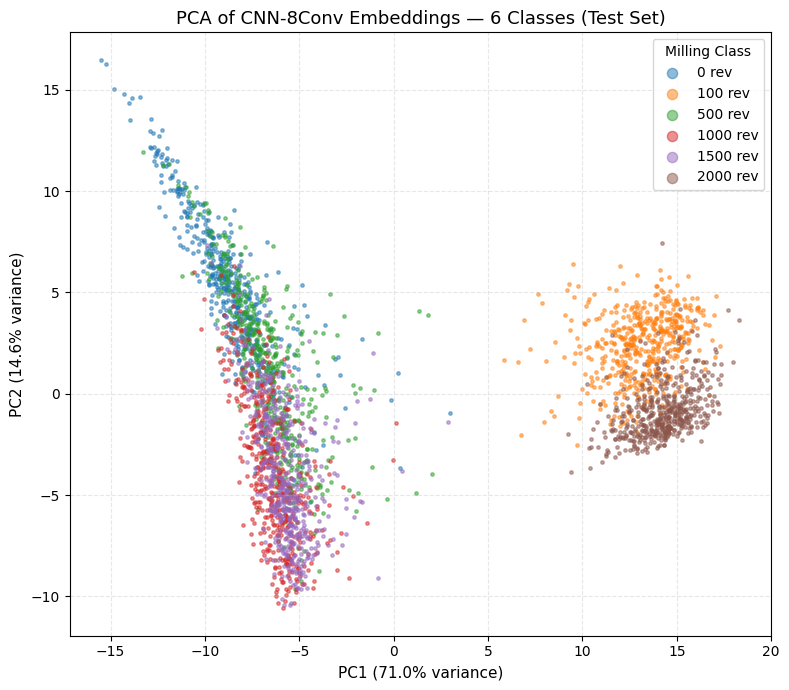

Saved: pca_embeddings.png


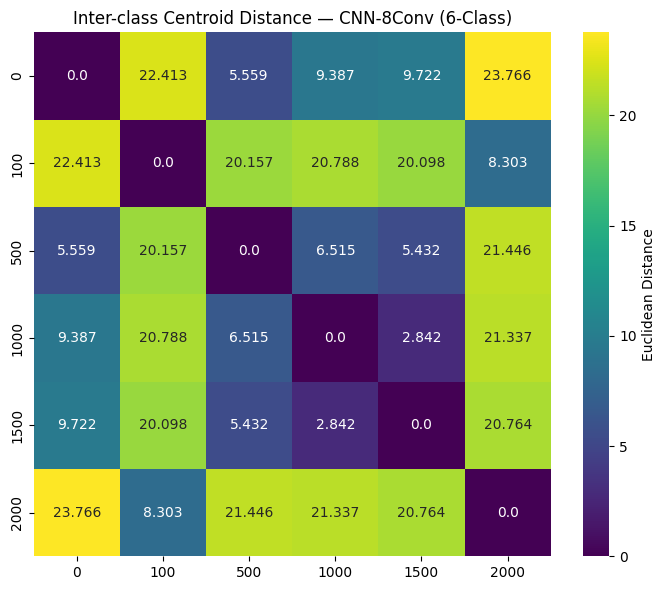

Saved: distance_heatmap.png


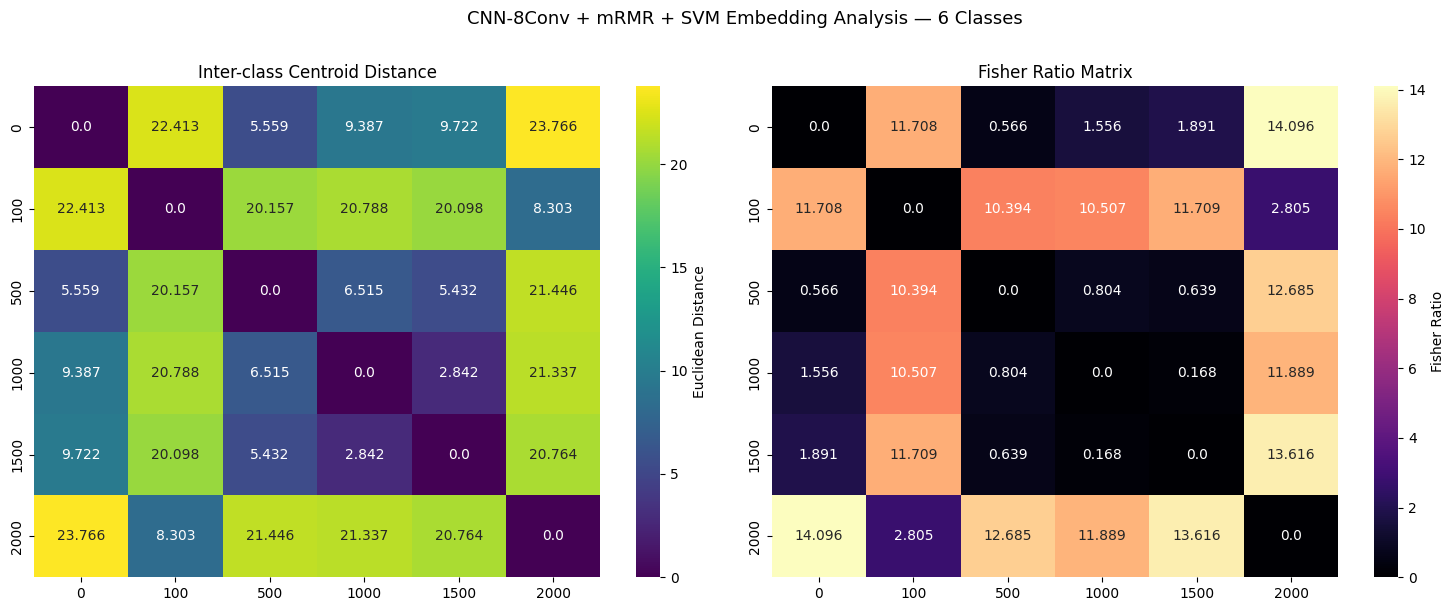

Saved: distance_fisher_side_by_side.png


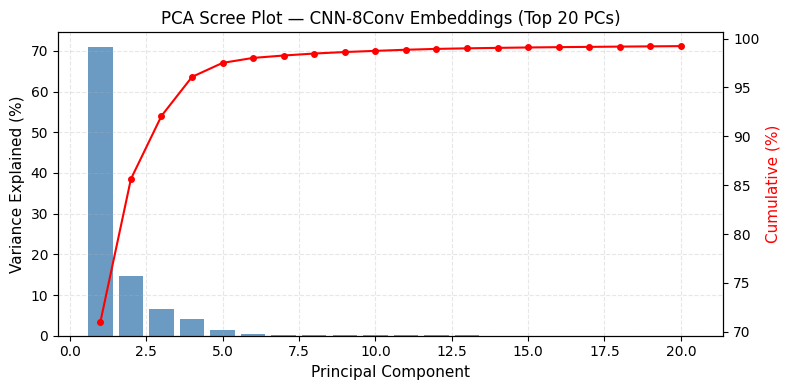

Saved: pca_scree_plot.png

All PCA results saved to: /home/jenarththan/Desktop/FYP/May11/Notebooks/Custom/CNN8_May11_Results/PCA_Analysis
PC1+PC2 explains : 85.6%
PCs for 95% var  : 4


In [9]:
# ================================================
# Cell 9 — PCA Analysis of CNN Embeddings
# ================================================
# seaborn/scipy/sklearn PCA: heatmaps, centroid distances, 2D projection
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from glob import glob

PCA_DIR = os.path.join(OUTPUT_DIR, "PCA_Analysis")
os.makedirs(PCA_DIR, exist_ok=True)


# Load 512-d BN-normalised embeddings for PCA.
# Despite low CNN accuracy, BN normalisation may produce
# compact, well-scaled clusters that the SVM exploits effectively.
# Load CNN embeddings saved by Cell 6
test_embs = np.load(os.path.join(OUTPUT_DIR, "test_embs.npy"))
y_true    = np.load(os.path.join(OUTPUT_DIR, "test_y.npy"))

# Find predictions CSV (SVM predictions saved by Cell 8)
pred_csvs = glob(os.path.join(OUTPUT_DIR, "predictions_*.csv"))
assert pred_csvs, f"No predictions CSV found in {OUTPUT_DIR}. Run Cell 8 first."
pred_df      = pd.read_csv(pred_csvs[0])
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
y_pred = np.array([label_to_idx[str(l)] for l in pred_df["Pred Label"].values])

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'][:NUM_CLASSES]

print(f"Embeddings : {test_embs.shape}")
print(f"True labels: {y_true.shape}")
print(f"Classes    : {CLASS_NAMES}")
print(f"PCA output : {PCA_DIR}")


# ── PCA 2-D projection ─────────────────────────────────────────
# PCA on 512-d BN embeddings — cluster structure may explain
# why SVM gains significantly despite poor CNN-head accuracy.
# ── PCA 2D scatter ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
Z   = pca.fit_transform(test_embs)
var = pca.explained_variance_ratio_
print(f"\nExplained variance: PC1={var[0]:.3f}  PC2={var[1]:.3f}  Total={var.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
for i, name in enumerate(CLASS_NAMES):
    idx = (y_true == i)
    ax.scatter(Z[idx, 0], Z[idx, 1], s=6, alpha=0.5, label=f'{name} rev', color=COLORS[i])
ax.set_title(f'PCA of CNN-8Conv Embeddings — {NUM_CLASSES} Classes (Test Set)', fontsize=13)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)', fontsize=11)
ax.legend(markerscale=3, fontsize=10, title='Milling Class')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_embeddings.png"), dpi=300)
plt.show()
print("Saved: pca_embeddings.png")


# Inter-class centroid Euclidean distances in 512-d embedding space
# ── Centroid distances ──────────────────────────
centroids, intra_spread = [], []
for i in range(NUM_CLASSES):
    Xc = test_embs[y_true == i]
    mu = Xc.mean(axis=0)
    centroids.append(mu)
    intra_spread.append(np.mean(np.linalg.norm(Xc - mu, axis=1)))
centroids    = np.vstack(centroids)
intra_spread = np.array(intra_spread)

inter   = cdist(centroids, centroids, metric='euclidean')
dist_df = pd.DataFrame(inter, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=ax,
            cbar_kws={'label': 'Euclidean Distance'})
ax.set_title(f'Inter-class Centroid Distance — CNN-8Conv ({NUM_CLASSES}-Class)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_heatmap.png"), dpi=300)
plt.show()
print("Saved: distance_heatmap.png")


# Fisher ratio + distance heatmaps side by side for paper figure
# ── Fisher ratio + side-by-side ─────────────────
intra_var = intra_spread ** 2
F = np.zeros((NUM_CLASSES, NUM_CLASSES))
for a in range(NUM_CLASSES):
    for b in range(NUM_CLASSES):
        if a != b:
            F[a, b] = (inter[a, b] ** 2) / (intra_var[a] + intra_var[b] + 1e-8)
fish_df = pd.DataFrame(F, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'Euclidean Distance'})
axes[0].set_title('Inter-class Centroid Distance', fontsize=12)
sns.heatmap(fish_df.round(3), annot=True, fmt='', cmap='magma', ax=axes[1],
            cbar_kws={'label': 'Fisher Ratio'})
axes[1].set_title('Fisher Ratio Matrix', fontsize=12)
fig.suptitle(f'CNN-8Conv + mRMR + SVM Embedding Analysis — {NUM_CLASSES} Classes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_fisher_side_by_side.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: distance_fisher_side_by_side.png")


# PCA scree: variance per component and cumulative variance
# ── Scree plot ──────────────────────────────────
pca_full = PCA(random_state=42).fit(test_embs)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax  = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100, color='steelblue', alpha=0.8)
ax2 = ax.twinx()
ax2.plot(range(1, 21), cum_var[:20]*100, color='red', marker='o', ms=4)
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_ylabel('Cumulative (%)', fontsize=11, color='red')
ax.set_title('PCA Scree Plot — CNN-8Conv Embeddings (Top 20 PCs)', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_scree_plot.png"), dpi=150)
plt.show()
print("Saved: pca_scree_plot.png")


# Export all PCA metrics to CSV for reproducibility
# ── Save CSVs ───────────────────────────────────
dist_df.to_csv(os.path.join(PCA_DIR, "pairwise_centroid_distance.csv"))
fish_df.to_csv(os.path.join(PCA_DIR, "pairwise_fisher_ratio.csv"))
pd.DataFrame({'Class': CLASS_NAMES, 'Intra_spread': intra_spread.round(4),
              'N_samples': [int(np.sum(y_true == i)) for i in range(NUM_CLASSES)]
}).to_csv(os.path.join(PCA_DIR, "class_spread_summary.csv"), index=False)
pd.DataFrame({'PC1': Z[:,0], 'PC2': Z[:,1],
              'True_Label': [CLASS_NAMES[i] for i in y_true]
}).to_csv(os.path.join(PCA_DIR, "pca_coordinates.csv"), index=False)

n_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"\nAll PCA results saved to: {PCA_DIR}")
print(f"PC1+PC2 explains : {cum_var[1]*100:.1f}%")
print(f"PCs for 95% var  : {n_95}")